# Q2. Unsupervised Learning — Customer Segmentation with K-Means and PCA

**Data source:** GitHub raw file at `https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data/q2_customers.csv`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Data Preparation

In [2]:
RAW_BASE_URL = "https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data"

def load_csv_from_github(filename):
    url = f"{RAW_BASE_URL}/{filename}"
    return pd.read_csv(url)

df = load_csv_from_github("q2_customers.csv")
print("Loaded from:", f"{RAW_BASE_URL}/q2_customers.csv")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
df.head()


Loaded from: https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data/q2_customers.csv
Shape: (500, 6)

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Scaling is essential before K-Means because the algorithm is distance-based. Features such as `annual_spend` operate on a much larger numeric range than features such as `visits_per_month`, so without scaling, high-magnitude variables would dominate the cluster assignment even if they are not the most meaningful behavioural drivers.

## 2. Choosing K — Elbow Method

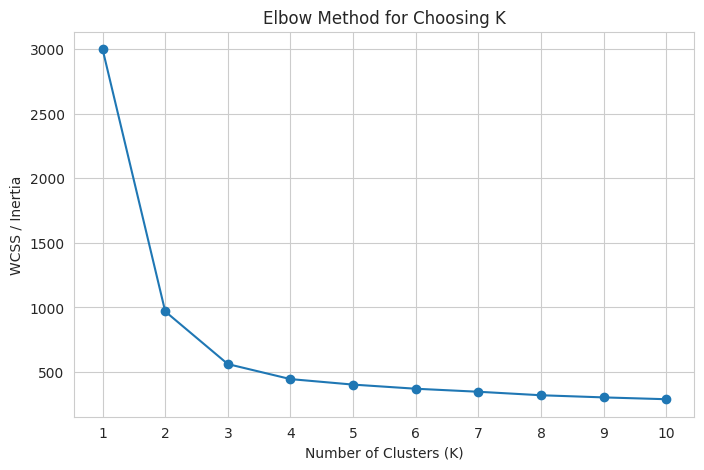

,K,WCSS
0,1,3000.000000
1,2,968.993871
2,3,561.253006
3,4,444.930276
4,5,402.371303
5,6,370.385393
6,7,346.954081
7,8,319.897475
8,9,303.282250
9,10,289.113979


In [4]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Choosing K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(range(1, 11))
plt.show()

pd.DataFrame({'K': range(1, 11), 'WCSS': wcss})

In [5]:
silhouette_rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_rows.append({'K': k, 'silhouette_score': silhouette_score(X_scaled, labels)})

pd.DataFrame(silhouette_rows)

,K,silhouette_score
0,2,0.582067
1,3,0.508181
2,4,0.455358
3,5,0.367101
4,6,0.350618
5,7,0.335220


The elbow is most visible around **K = 4**: inertia drops sharply from 1 to 4 clusters and then begins to flatten. Although the silhouette score is highest at K = 2, choosing 4 gives a more useful business segmentation because it preserves meaningful customer variety while still being close to the elbow.

## 3. K-Means Clustering

In [6]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop(columns='cluster').columns
).round(2)

print("Cluster counts:")
print(df['cluster'].value_counts().sort_index())
print("\nCluster centroids:")
centroids_df

Cluster counts:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Cluster centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.07,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54


In [7]:
cluster_profile = df.groupby('cluster').mean(numeric_only=True).round(2)
cluster_profile

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.68,14847.37,14.34,558.97,9.08,2.11
1,57.04,89814.08,2.46,5296.36,148.00,7.49
2,40.39,43340.73,8.19,2021.68,35.19,4.42
3,56.52,89036.16,2.59,5750.95,65.22,7.54


### Business interpretation of the clusters

- **Cluster 0**: younger customers with low annual spend, smaller baskets, and frequent recent visits — likely value-driven regular shoppers.
- **Cluster 1**: older, very high-spending customers who buy across many categories but have long gaps since their last visit — likely premium but at-risk customers.
- **Cluster 2**: middle-of-the-road customers across most metrics — a broad mainstream segment.
- **Cluster 3**: older, high-spending, broad-category shoppers with more recent activity than Cluster 1 — likely loyal premium customers.

## 4. Dimensionality Reduction with PCA

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained_variance_df = pd.DataFrame({
    'Principal Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': pca.explained_variance_ratio_
})

loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df.drop(columns='cluster').columns,
    columns=['PC1', 'PC2']
).round(3)

print("Explained variance ratio:")
display(explained_variance_df)

print("Feature loadings:")
loadings_df

Explained variance ratio:


,Principal Component,Explained Variance Ratio
0,PC1,0.835604
1,PC2,0.055688


Feature loadings:


,PC1,PC2
age,0.412,-0.259
annual_spend,0.422,-0.033
visits_per_month,-0.410,0.208
basket_size,0.412,-0.195
days_since_last_visit,0.379,0.911
num_categories_purchased,0.414,-0.140


PC1 explains the large majority of the variation and appears to capture an axis moving from **frequent/recent, lower-value shopping** toward **older, bigger-basket, higher-spend, wider-category purchasing**. PC2 is dominated by **`days_since_last_visit`**, so it mainly separates customers by recency and potential churn risk.

## 5. Cluster Visualisation

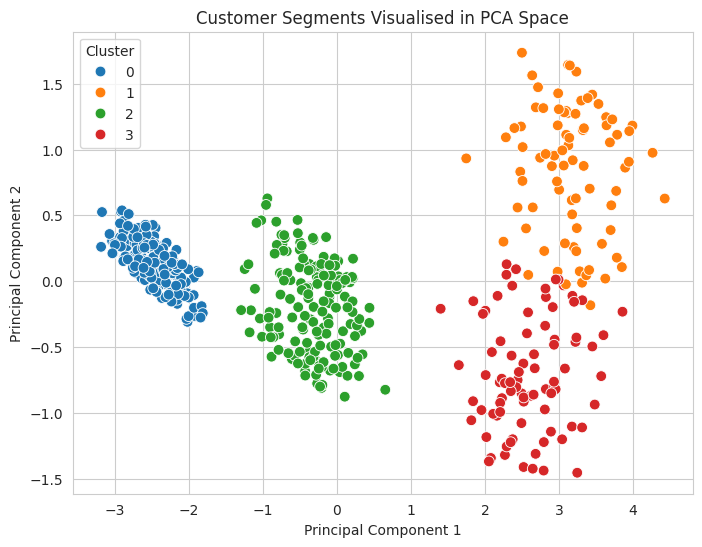

In [9]:
pca_plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_plot_df['cluster'] = df['cluster']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=60)
plt.title('Customer Segments Visualised in PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()